## Query Transformations

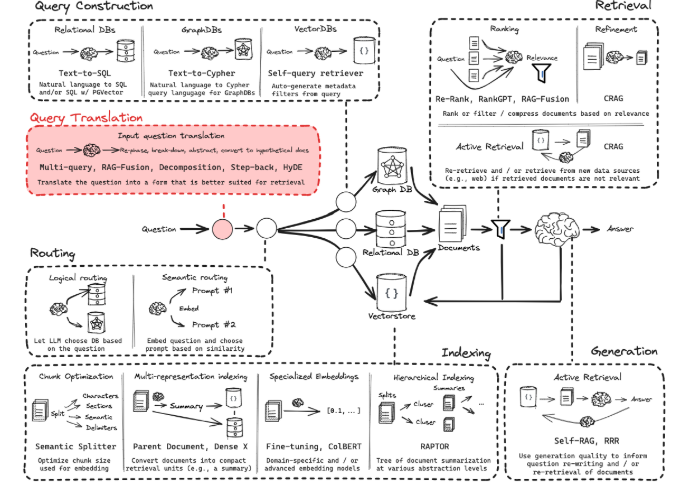

### Multi-Query Retrieval

#### 一、核心动机:解决用户提问的不确定性
在基础RAG中，直接用用户的问题去向量数据库搜索，但是存在问题：
- 用词差异：用户的问题可能比较模糊，有歧义，或者使用的词汇与文档库中的词汇不完全匹配
- 语义偏移：由于嵌入模型将文本转化为向量时存在细微语义差别，用户提问的原始表达在高维空间里可能离真正相关的文档并不近
- 多查询：既然一个提问可能搜不到，那我们就换着花样多问几次，以此来提高“撞大运”搜到正确资料的概率。这被称为一种“散弹枪式（Shotgun Approach）”的方法，旨在通过增加检索范围来提升系统的可靠性

#### 二、多查询的工作流程
多查询技术将RAG的第一步进行了扩展，具体分为以下四个步骤：
1. 问题重写(Query Rewriting): 利用LLM将用户输入的一个原始问题，改写为3-5个意思相同但侧重点、措辞不同的子问题 
2. 并行检索(Parallel Retrieval)：针对这每一个生成出来的新问题，分别独立地去向量数据库里执行检索
3. 结果去重与合并(unique Union): 由于多个问题可能会检索到重复的文档，系统会把所有找回来的文档进行收集去重，取唯一并集
4. 最终生成：将这一堆筛选出来、覆盖面更广的文档作为背景资料塞给LLM，让它生成最终答案

In [1]:
# Indexing
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
print(blog_docs)


c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
#Split
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=300, chunk_overlap=50)
splits = text_splitter.split_documents(blog_docs)  
print(splits)  # 打印分割后的 Document 对象列表

Created a chunk of size 492, which is longer than the specified 300
Created a chunk of size 341, which is longer than the specified 300
Created a chunk of size 336, which is longer than the specified 300
Created a chunk of size 2671, which is longer than the specified 300
Created a chunk of size 716, which is longer than the specified 300
Created a chunk of size 620, which is longer than the specified 300
Created a chunk of size 1373, which is longer than the specified 300
Created a chunk of size 738, which is longer than the specified 300
Created a chunk of size 1281, which is longer than the specified 300
Created a chunk of size 363, which is longer than the specified 300
Created a chunk of size 344, which is longer than the specified 300
Created a chunk of size 398, which is longer than the specified 300
Created a chunk of size 370, which is longer than the specified 300
Created a chunk of size 542, which is longer than the specified 300
Created a chunk of size 2352, which is longer

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Planning'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-0

In [3]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory="./chroma_db"  # 向量库保存路径
)
vectorstore.persist()  # 持久化存储
retriever = vectorstore.as_retriever() 

C:\Users\23017\AppData\Local\Temp\ipykernel_29524\2382097115.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 916.83it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\23017\AppData\Local\Temp\ipykernel_29524\2382097115.py:15: LangChainDep

#### Prompt

In [10]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.chat_models.tongyi import ChatTongyi  # 通义千问
from langchain_core.load import dumps, loads
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough
import os 
# 通义千问配置（使用你提供的API Key和模型）
LLM_MODEL = "qwen-turbo"  # 通义千问免费模型
TEMPERATURE = 0.0  # 生成温度（0=稳定输出）
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY

In [12]:
llm = ChatTongyi(
  model = LLM_MODEL,
  temperature = TEMPERATURE,
)

template = """你是一个AI助手，你的任务是为给定的用户问题生成5个不同版本的表述，
用于从向量数据库中检索相关文档。通过生成多视角的问题，可以帮助克服基于距离的相似度搜索的局限性。
要求：
1. 严格生成5个问题，每个问题单独一行
2. 保持问题的核心语义不变
3. 只输出问题，不要额外解释
原始问题：{question}"""

prompt_perspectives = PromptTemplate.from_template(template)

#构建多查询生成链
generate_queries = (
    prompt_perspectives 
    | llm 
    | StrOutputParser() 
    | (lambda x: [q.strip() for q in x.split("\n") if q.strip()])  # 清理空行和空格
)

#### Retrieval

In [13]:
#文档去重
def get_unique_union(documents = list[list]):
  flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
  unique_docs = list(set(flattened_docs))
  return [loads(doc) for doc in unique_docs]

#检索链
question = "什么是LLM智能体的任务分解？"
retrieval_chain = generate_queries | retriever.map() | get_unique_union
docs = retrieval_chain.invoke({"question":question})
print(f"检索到的唯一文档数量：{len(docs)}")

rag_template = """基于以下上下文回答问题，仅使用上下文信息，不要编造内容：

{context}

问题：{question}"""
prompt = PromptTemplate.from_template(rag_template)

final_rag_chain = (
    {"context": retrieval_chain, 
     "question": itemgetter("question")} 
    | prompt
    | llm  # 使用通义千问生成最终回答
    | StrOutputParser()
)

# 执行问答并输出结果
response = final_rag_chain.invoke({"question":question})
print(response)

C:\Users\23017\AppData\Local\Temp\ipykernel_29524\392559474.py:5: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  return [loads(doc) for doc in unique_docs]


检索到的唯一文档数量：4
LLM智能体的任务分解是将用户的请求解析为多个任务，每个任务有四个属性：任务类型、ID、依赖关系和参数。这一过程通过少量示例来引导LLM完成任务解析和规划。


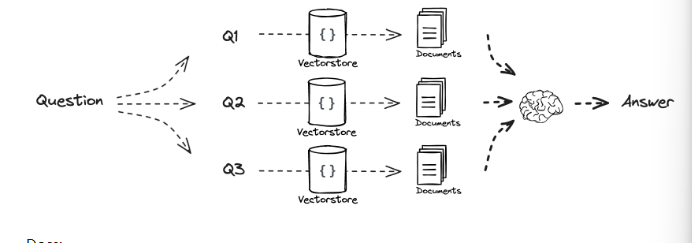